In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split

In [3]:
# Load dataset
df = pd.read_feather("/kaggle/input/diagnoise-me/diagnose_en_dataset.feather").head(15000)
print(df[["Patient", "Doctor"]].head())

# Combine question and answer into dialogue format
df["text"] = df.apply(lambda row: f"Patient: {row['Patient']}\nDoctor: {row['Doctor']}", axis=1)

                                             Patient  \
0  Hi doctor,I am just wondering what is abutting...   
1  Hi doctor, I am a 26 year old male. I am 5 fee...   
2  Hello doctor, I am 48 years old. I am experien...   
3  Hello doctor, I have multiple small cysts in b...   
4  Hi doctor, During masturbation I just rub the ...   

                                              Doctor  
0  Hi. I have gone through your query with dilige...  
1  Hello. I have gone through your information an...  
2  Hi. For further doubts consult a sexologist on...  
3  Hello. I just read your query. See Kalarachi K...  
4  Hi. For further doubts consult a sexologist on...  


In [4]:
# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")

batch_size = 2
train_ds = tf.data.Dataset.from_tensor_slices(train_df["text"].values)
train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(batch_size)

val_ds = tf.data.Dataset.from_tensor_slices(val_df["text"].values)
val_ds = val_ds.shuffle(buffer_size=len(val_df)).batch(batch_size)

Train size: (12000, 5)
Validation size: (3000, 5)


In [5]:
gpt2_lm = keras_nlp.models.GPT2CausalLM.from_preset("gpt2_base_en")

# Compile model for language modeling
gpt2_lm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5))

In [6]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3903s 639ms/step - loss: 0.6133 - sparse_categorical_accuracy: 0.5416 - val_loss: 0.5231 - val_sparse_categorical_accuracy: 0.5878
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3823s 637ms/step - loss: 0.5030 - sparse_categorical_accuracy: 0.5980 - val_loss: 0.5120 - val_sparse_categorical_accuracy: 0.5930
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3826s 638ms/step - loss: 0.4735 - sparse_categorical_accuracy: 0.6136 - val_loss: 0.5083 - val_sparse_categorical_accuracy: 0.5958
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3818s 636ms/step - loss: 0.4524 - sparse_categorical_accuracy: 0.6232 - val_loss: 0.5096 - val_sparse_categorical_accuracy: 0.5957
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3818s 636ms/step - loss: 0.4302 - sparse_categorical_accuracy: 0.6334 - val_loss: 0.5137 - val_sparse_categorical_accuracy: 0.5950


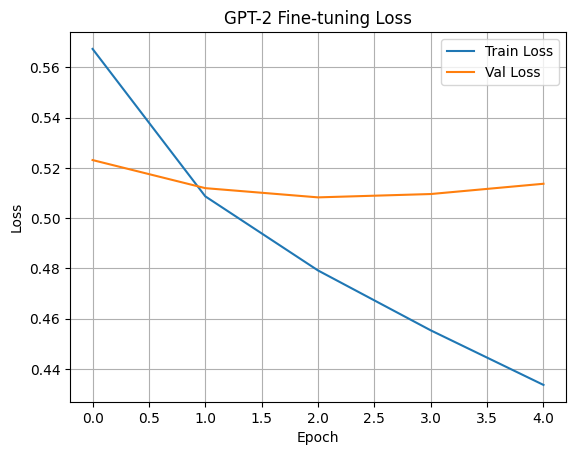

In [7]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_dialog.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()

In [8]:
# Create a list to hold test results
results = []

# Generate and collect answers for 10 random questions
sample_df = df.sample(10, random_state=42)[["Patient", "Doctor"]]

for i, row in sample_df.iterrows():
    question = row["Patient"]
    true_answer = row["Doctor"]
    prompt = f"Patient: {question}\nDoctor:"
    
    # Generate model response
    generated = gpt2_lm.generate(prompt, max_length=100)
    
    # Save to results
    results.append({
        "question": question,
        "true_answer": true_answer,
        "generated_answer": generated
    })

# Save results to a DataFrame and then to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/test_results.csv", index=False)
print("✅ Saved test results to /kaggle/working/test_results.csv")

✅ Saved test results to /kaggle/working/test_results.csv
